# Landslide Source Patch Classification

This notebook builds a patch-classification prototype for Eagle Creek using the aligned 30 m raster stack from the preprocessing pipeline and polygon landslide inventory labels.

Workflow:
- load a reduced raster feature stack
- rasterize landslide polygons to the DEM grid
- create spatial train/validation/test splits using raster blocks
- sample balanced positive and negative training patches
- train a patch classifier in PyTorch
- sweep probability thresholds on the validation set
- export a patch-based source probability raster and binary prediction raster

The exported probability map is a patch-level source-likelihood surface. It is not a pixel-perfect segmentation mask.


In [1]:
from pathlib import Path
import sys
import json
import copy
import random

import numpy as np
import pandas as pd
import geopandas as gpd
import rasterio
from rasterio.features import rasterize
import matplotlib.pyplot as plt

import torch
import torch.nn as nn
from torch.utils.data import Dataset, DataLoader

repo_root = Path("/home/abdullah/fire-debrisflow-ml")
src_dir = repo_root / "src"
if str(src_dir) not in sys.path:
    sys.path.insert(0, str(src_dir))

from deep.data import build_block_windows, split_block_windows, extract_patch_origins, load_feature_target_stack


## Controls

Edit these paths and hyperparameters first. The defaults are set up for the Eagle Creek 30 m stack.


In [2]:
aoi_path = Path("/mnt/c/Users/amehedi/Downloads/eaglecreek/eaglecreek.shp")
label_poly_path = Path("/mnt/c/Users/amehedi/Downloads/eaglecreek/eaglecreek_landslide_inventory_2009_2018.geojson")
features_dir = Path("/mnt/c/Users/amehedi/Downloads/eaglecreek/output/30m")

run_name = "ls_source_class_30m"
run_dir = features_dir / run_name
run_dir.mkdir(parents=True, exist_ok=True)

feature_names = [
    "topographic__elevation",
    "topographic__slope",
    "topographic__curvature",
    "topographic__specific_contributing_area",
    "burn__severity",
    "soil__thickness",
    "soil__internal_friction_angle",
    "soil__mode_total_cohesion",
]

patch_size = 64
stride = 32
block_size = 512
min_valid_fraction = 0.95
min_positive_pixels = 1
label_buffer_pixels = 0

train_frac = 0.60
val_frac = 0.20
test_frac = 0.20
train_neg_to_pos_ratio = 2.0
val_neg_to_pos_ratio = 2.0
keep_test_natural = True
random_state = 42
max_split_retries = 50
min_positive_patches = {"train": 20, "val": 5, "test": 5}

base_channels = 32
dropout = 0.20
learning_rate = 1e-3
weight_decay = 1e-5
max_epochs = 40
patience = 8
device = "cuda" if torch.cuda.is_available() else "cpu"
batch_size = 8 if device == "cuda" else 4

thresholds = [round(t, 2) for t in np.arange(0.05, 0.96, 0.05)]
all_touched = True

ref_path = features_dir / "topographic__elevation.tif"
label_raster_path = run_dir / "landslide_label.tif"
prob_out_path = run_dir / "landslide_source_probability_patchcls.tif"
mask_out_path = run_dir / "landslide_source_prediction_patchcls.tif"
history_path = run_dir / "training_history.csv"
threshold_path = run_dir / "threshold_sweep.csv"
model_path = run_dir / "patch_classifier.pt"

feature_paths = [features_dir / f"{name}.tif" for name in feature_names]
missing = [str(p) for p in feature_paths if not p.exists()]
if missing:
    raise FileNotFoundError("Missing features:\n" + "\n".join(missing))

config_snapshot = {
    "aoi_path": str(aoi_path),
    "label_poly_path": str(label_poly_path),
    "features_dir": str(features_dir),
    "feature_names": feature_names,
    "patch_size": patch_size,
    "stride": stride,
    "block_size": block_size,
    "min_valid_fraction": min_valid_fraction,
    "min_positive_pixels": min_positive_pixels,
    "label_buffer_pixels": label_buffer_pixels,
    "train_frac": train_frac,
    "val_frac": val_frac,
    "test_frac": test_frac,
    "train_neg_to_pos_ratio": train_neg_to_pos_ratio,
    "val_neg_to_pos_ratio": val_neg_to_pos_ratio,
    "keep_test_natural": keep_test_natural,
    "random_state": random_state,
    "max_split_retries": max_split_retries,
    "min_positive_patches": min_positive_patches,
    "base_channels": base_channels,
    "dropout": dropout,
    "learning_rate": learning_rate,
    "weight_decay": weight_decay,
    "max_epochs": max_epochs,
    "patience": patience,
    "device": device,
    "batch_size": batch_size,
    "thresholds": thresholds,
    "all_touched": all_touched,
}

with open(run_dir / "config_snapshot.json", "w") as f:
    json.dump(config_snapshot, f, indent=2)

print("Run directory:", run_dir)
print("Device:", device)
print("Features:", feature_names)


Run directory: /mnt/c/Users/amehedi/Downloads/eaglecreek/output/30m/ls_source_class_30m
Device: cpu
Features: ['topographic__elevation', 'topographic__slope', 'topographic__curvature', 'topographic__specific_contributing_area', 'burn__severity', 'soil__thickness', 'soil__internal_friction_angle', 'soil__mode_total_cohesion']


## Helpers

These functions handle label buffering, patch extraction, class balancing, model definition, metrics, training, and patch-to-raster inference.


In [3]:
def set_seed(seed: int) -> None:
    random.seed(seed)
    np.random.seed(seed)
    torch.manual_seed(seed)
    if torch.cuda.is_available():
        torch.cuda.manual_seed_all(seed)


def dilate_binary_mask(mask: np.ndarray, iterations: int = 1) -> np.ndarray:
    out = mask.astype(bool)
    for _ in range(iterations):
        padded = np.pad(out, 1, mode="constant", constant_values=False)
        neighbors = []
        for dr in (-1, 0, 1):
            for dc in (-1, 0, 1):
                neighbors.append(
                    padded[1 + dr : 1 + dr + out.shape[0], 1 + dc : 1 + dc + out.shape[1]]
                )
        out = np.logical_or.reduce(neighbors)
    return out.astype("uint8")


def compute_channel_norm_stats(x: np.ndarray, mask: np.ndarray) -> tuple[np.ndarray, np.ndarray]:
    means = np.zeros(x.shape[0], dtype="float32")
    stds = np.ones(x.shape[0], dtype="float32")
    for c in range(x.shape[0]):
        vals = x[c][mask]
        vals = vals[np.isfinite(vals)]
        if vals.size == 0:
            means[c] = 0.0
            stds[c] = 1.0
        else:
            means[c] = float(vals.mean())
            stds[c] = max(float(vals.std()), 1e-6)
    return means, stds


def apply_channel_norm(x: np.ndarray, means: np.ndarray, stds: np.ndarray) -> np.ndarray:
    x_norm = (x - means[:, None, None]) / stds[:, None, None]
    x_norm = np.clip(x_norm, -20.0, 20.0)
    x_norm = np.nan_to_num(x_norm, nan=0.0, posinf=0.0, neginf=0.0)
    return x_norm.astype("float32")


class PatchClassificationDataset(Dataset):
    def __init__(self, x: np.ndarray, origins: list[tuple[int, int]], labels: list[int], patch_size: int) -> None:
        self.x = x
        self.origins = list(origins)
        self.labels = np.asarray(labels, dtype="float32")
        self.patch_size = patch_size

    def __len__(self) -> int:
        return len(self.origins)

    def __getitem__(self, idx: int):
        r, c = self.origins[idx]
        ps = self.patch_size
        x_patch = self.x[:, r : r + ps, c : c + ps]
        y_patch = self.labels[idx]
        return torch.from_numpy(x_patch).float(), torch.tensor([y_patch], dtype=torch.float32)


class ConvBlock(nn.Module):
    def __init__(self, in_channels: int, out_channels: int) -> None:
        super().__init__()
        groups = 8 if out_channels % 8 == 0 else 1
        self.block = nn.Sequential(
            nn.Conv2d(in_channels, out_channels, kernel_size=3, padding=1, bias=False),
            nn.GroupNorm(groups, out_channels),
            nn.ReLU(inplace=True),
            nn.Conv2d(out_channels, out_channels, kernel_size=3, padding=1, bias=False),
            nn.GroupNorm(groups, out_channels),
            nn.ReLU(inplace=True),
        )

    def forward(self, x: torch.Tensor) -> torch.Tensor:
        return self.block(x)


class PatchCNNClassifier(nn.Module):
    def __init__(self, in_channels: int, base_channels: int = 32, dropout: float = 0.2) -> None:
        super().__init__()
        c = base_channels
        self.enc1 = ConvBlock(in_channels, c)
        self.enc2 = ConvBlock(c, c * 2)
        self.enc3 = ConvBlock(c * 2, c * 4)
        self.pool = nn.MaxPool2d(2)
        self.head = nn.Sequential(
            nn.AdaptiveAvgPool2d(1),
            nn.Flatten(),
            nn.Linear(c * 4, c * 2),
            nn.ReLU(inplace=True),
            nn.Dropout(dropout),
            nn.Linear(c * 2, 1),
        )

    def forward(self, x: torch.Tensor) -> torch.Tensor:
        x = self.enc1(x)
        x = self.pool(x)
        x = self.enc2(x)
        x = self.pool(x)
        x = self.enc3(x)
        return self.head(x)


def make_patch_labels(
    origins: list[tuple[int, int]],
    y: np.ndarray,
    patch_size: int,
    min_positive_pixels: int = 1,
) -> list[int]:
    labels = []
    for r, c in origins:
        n_pos = int(y[r : r + patch_size, c : c + patch_size].sum())
        labels.append(1 if n_pos >= min_positive_pixels else 0)
    return labels


def split_positive_negative(
    origins: list[tuple[int, int]],
    y: np.ndarray,
    patch_size: int,
    min_positive_pixels: int = 1,
) -> tuple[list[tuple[int, int]], list[tuple[int, int]]]:
    labels = make_patch_labels(origins, y, patch_size, min_positive_pixels=min_positive_pixels)
    pos = [origin for origin, label in zip(origins, labels) if label == 1]
    neg = [origin for origin, label in zip(origins, labels) if label == 0]
    return pos, neg


def sample_balanced_origins(
    pos_origins: list[tuple[int, int]],
    neg_origins: list[tuple[int, int]],
    neg_to_pos_ratio: float = 2.0,
    seed: int = 42,
) -> tuple[list[tuple[int, int]], list[int]]:
    if len(pos_origins) == 0:
        raise ValueError("No positive origins available for balanced sampling.")

    rng = np.random.default_rng(seed)
    n_neg_keep = min(len(neg_origins), int(np.ceil(len(pos_origins) * neg_to_pos_ratio)))
    if n_neg_keep > 0:
        keep_idx = rng.choice(len(neg_origins), size=n_neg_keep, replace=False)
        neg_keep = [neg_origins[i] for i in keep_idx]
    else:
        neg_keep = []

    origins = list(pos_origins) + list(neg_keep)
    labels = [1] * len(pos_origins) + [0] * len(neg_keep)
    order = rng.permutation(len(origins))
    origins = [origins[i] for i in order]
    labels = [labels[i] for i in order]
    return origins, labels


def build_spatial_patch_split(
    valid_mask: np.ndarray,
    y: np.ndarray,
    patch_size: int,
    stride: int,
    block_size: int,
    min_valid_fraction: float,
    min_positive_pixels: int,
    train_frac: float,
    val_frac: float,
    test_frac: float,
    random_state: int,
    max_retries: int,
    min_positive_patches: dict,
):
    windows = build_block_windows(y.shape[0], y.shape[1], block_size=block_size)

    for attempt in range(max_retries):
        seed = random_state + attempt
        split_windows = split_block_windows(
            windows,
            train_frac=train_frac,
            val_frac=val_frac,
            test_frac=test_frac,
            random_state=seed,
        )

        split_data = {}
        ok = True
        for split_name in ("train", "val", "test"):
            candidates = extract_patch_origins(
                valid_mask,
                split_windows[split_name],
                patch_size=patch_size,
                stride=stride,
                min_valid_fraction=min_valid_fraction,
            )
            pos, neg = split_positive_negative(
                candidates,
                y,
                patch_size=patch_size,
                min_positive_pixels=min_positive_pixels,
            )
            split_data[split_name] = {
                "candidates": candidates,
                "pos_origins": pos,
                "neg_origins": neg,
            }
            if len(pos) < int(min_positive_patches.get(split_name, 1)):
                ok = False
                break

        if ok:
            return split_windows, split_data, seed

    raise ValueError(
        "Could not build a spatial split with enough positive patches. "
        "Reduce min_positive_patches, reduce patch_size, or change random_state."
    )


def binary_scores(y_true: np.ndarray, y_prob: np.ndarray, threshold: float = 0.5) -> dict:
    y_true = np.asarray(y_true).astype(np.uint8)
    y_prob = np.asarray(y_prob).astype(np.float32)
    y_pred = (y_prob >= threshold).astype(np.uint8)

    tp = int(((y_pred == 1) & (y_true == 1)).sum())
    tn = int(((y_pred == 0) & (y_true == 0)).sum())
    fp = int(((y_pred == 1) & (y_true == 0)).sum())
    fn = int(((y_pred == 0) & (y_true == 1)).sum())

    precision = tp / max(tp + fp, 1)
    recall = tp / max(tp + fn, 1)
    f1 = 2.0 * precision * recall / max(precision + recall, 1e-8)
    iou = tp / max(tp + fp + fn, 1)
    accuracy = (tp + tn) / max(tp + tn + fp + fn, 1)

    return {
        "precision": precision,
        "recall": recall,
        "f1": f1,
        "iou": iou,
        "accuracy": accuracy,
        "tp": tp,
        "fp": fp,
        "fn": fn,
        "tn": tn,
    }


def collect_loader_predictions(model, loader, device):
    model.eval()
    probs = []
    truths = []
    with torch.no_grad():
        for xb, yb in loader:
            xb = xb.to(device)
            logits = model(xb)
            prob = torch.sigmoid(logits).detach().cpu().numpy().reshape(-1)
            probs.append(prob)
            truths.append(yb.numpy().reshape(-1))
    return np.concatenate(truths), np.concatenate(probs)


def evaluate_loader(model, loader, device, criterion, threshold: float = 0.5):
    model.eval()
    losses = []
    probs = []
    truths = []

    with torch.no_grad():
        for xb, yb in loader:
            xb = xb.to(device)
            yb = yb.to(device)
            logits = model(xb)
            loss = criterion(logits, yb)
            losses.append(float(loss.mean().item()))
            probs.append(torch.sigmoid(logits).detach().cpu().numpy().reshape(-1))
            truths.append(yb.detach().cpu().numpy().reshape(-1))

    y_true = np.concatenate(truths)
    y_prob = np.concatenate(probs)
    metrics = binary_scores(y_true, y_prob, threshold=threshold)
    metrics["loss"] = float(np.mean(losses)) if losses else float("nan")
    return metrics


def _tile_starts(size: int, patch_size: int, stride: int) -> list[int]:
    if size < patch_size:
        return [0]
    starts = list(range(0, size - patch_size + 1, stride))
    last = size - patch_size
    if starts[-1] != last:
        starts.append(last)
    return starts


def infer_patch_probability_map(
    model,
    x: np.ndarray,
    valid_mask: np.ndarray,
    patch_size: int,
    stride: int,
    device: str,
    nodata_value: float = -9999.0,
) -> np.ndarray:
    _, h, w = x.shape
    pred_sum = np.zeros((h, w), dtype="float32")
    pred_count = np.zeros((h, w), dtype="float32")

    row_starts = _tile_starts(h, patch_size, stride)
    col_starts = _tile_starts(w, patch_size, stride)

    model.eval()
    with torch.no_grad():
        for r0 in row_starts:
            r1 = min(r0 + patch_size, h)
            for c0 in col_starts:
                c1 = min(c0 + patch_size, w)
                patch = x[:, r0:r1, c0:c1]

                padded = np.zeros((x.shape[0], patch_size, patch_size), dtype="float32")
                padded[:, : patch.shape[1], : patch.shape[2]] = patch

                xb = torch.from_numpy(padded[None, :, :, :]).to(device)
                prob = float(torch.sigmoid(model(xb)).detach().cpu().numpy().reshape(-1)[0])
                pred_sum[r0:r1, c0:c1] += prob
                pred_count[r0:r1, c0:c1] += 1.0

    pred_count[pred_count == 0.0] = 1.0
    pred = pred_sum / pred_count
    pred[~valid_mask] = nodata_value
    return pred.astype("float32")


def save_float_tif(array: np.ndarray, profile: dict, out_path: Path, nodata_value: float = -9999.0) -> None:
    out_profile = profile.copy()
    out_profile.update(driver="GTiff", dtype="float32", count=1, nodata=nodata_value)
    with rasterio.open(out_path, "w", **out_profile) as dst:
        dst.write(array.astype("float32"), 1)


def save_uint8_tif(array: np.ndarray, profile: dict, out_path: Path, nodata_value: int = 255) -> None:
    out_profile = profile.copy()
    out_profile.update(driver="GTiff", dtype="uint8", count=1, nodata=nodata_value)
    with rasterio.open(out_path, "w", **out_profile) as dst:
        dst.write(array.astype("uint8"), 1)


## Rasterize landslide polygons to the DEM grid

The polygon inventory is reprojected to the DEM grid, clipped to the AOI, optionally buffered in raster space, and written to the run directory as the training label raster.


In [4]:
with rasterio.open(ref_path) as src:
    ref_profile = src.profile.copy()
    ref_crs = src.crs
    ref_transform = src.transform
    ref_height = src.height
    ref_width = src.width
    ref_arr = src.read(1)
    ref_nodata = src.nodata if src.nodata is not None else -9999.0

valid_ref = np.isfinite(ref_arr)
valid_ref &= ~np.isclose(ref_arr, ref_nodata)

aoi = gpd.read_file(aoi_path).to_crs(ref_crs)
labels = gpd.read_file(label_poly_path).to_crs(ref_crs)
labels = gpd.overlay(labels, aoi[["geometry"]], how="intersection")
labels = labels[~labels.geometry.is_empty].copy()

label_arr = rasterize(
    ((geom, 1) for geom in labels.geometry),
    out_shape=(ref_height, ref_width),
    transform=ref_transform,
    fill=0,
    all_touched=all_touched,
    dtype="uint8",
)

if label_buffer_pixels > 0:
    label_arr = dilate_binary_mask(label_arr, iterations=label_buffer_pixels)

label_arr[~valid_ref] = 255

label_profile = ref_profile.copy()
label_profile.update(driver="GTiff", dtype="uint8", count=1, nodata=255)
with rasterio.open(label_raster_path, "w", **label_profile) as dst:
    dst.write(label_arr, 1)

print("Saved label raster:", label_raster_path)
print("Positive pixels:", int((label_arr == 1).sum()))
print("Valid pixels:", int((label_arr != 255).sum()))

Saved label raster: /mnt/c/Users/amehedi/Downloads/eaglecreek/output/30m/ls_source_class_30m/landslide_label.tif
Positive pixels: 990
Valid pixels: 375359


## Load the raster feature stack

Features are loaded as a `[channels, height, width]` array. The label raster is read on the same grid so the valid-mask logic stays consistent.


In [5]:
stack = load_feature_target_stack(feature_paths, label_raster_path)
X = stack["X"].astype("float32")
y = (stack["y"] > 0).astype("uint8")
valid_mask = stack["valid_mask"]
profile = stack["profile"]

print("X shape:", X.shape)
print("y shape:", y.shape)
print("Valid fraction:", float(valid_mask.mean()))
print("Positive fraction:", float(y[valid_mask].mean()))


X shape: (8, 642, 1368)
y shape: (642, 1368)
Valid fraction: 0.3941846113206172
Positive fraction: 0.0028596600181978364


## Build spatial train/validation/test splits and balanced training patches

The split is block-based to reduce spatial leakage. Training and validation are balanced by downsampling negative patches. The test set keeps the natural class distribution.


In [6]:
set_seed(random_state)

split_windows, split_data, split_seed = build_spatial_patch_split(
    valid_mask=valid_mask,
    y=y,
    patch_size=patch_size,
    stride=stride,
    block_size=block_size,
    min_valid_fraction=min_valid_fraction,
    min_positive_pixels=min_positive_pixels,
    train_frac=train_frac,
    val_frac=val_frac,
    test_frac=test_frac,
    random_state=random_state,
    max_retries=max_split_retries,
    min_positive_patches=min_positive_patches,
)

train_origins, train_labels = sample_balanced_origins(
    split_data["train"]["pos_origins"],
    split_data["train"]["neg_origins"],
    neg_to_pos_ratio=train_neg_to_pos_ratio,
    seed=split_seed,
)

val_origins, val_labels = sample_balanced_origins(
    split_data["val"]["pos_origins"],
    split_data["val"]["neg_origins"],
    neg_to_pos_ratio=val_neg_to_pos_ratio,
    seed=split_seed + 1,
)

if keep_test_natural:
    test_origins = split_data["test"]["candidates"]
    test_labels = make_patch_labels(
        test_origins,
        y,
        patch_size=patch_size,
        min_positive_pixels=min_positive_pixels,
    )
else:
    test_origins, test_labels = sample_balanced_origins(
        split_data["test"]["pos_origins"],
        split_data["test"]["neg_origins"],
        neg_to_pos_ratio=val_neg_to_pos_ratio,
        seed=split_seed + 2,
    )

split_summary = pd.DataFrame(
    [
        {
            "split": "train",
            "candidate_patches": len(split_data["train"]["candidates"]),
            "positive_candidates": len(split_data["train"]["pos_origins"]),
            "negative_candidates": len(split_data["train"]["neg_origins"]),
            "used_patches": len(train_origins),
            "used_positives": int(sum(train_labels)),
            "used_negatives": int(len(train_labels) - sum(train_labels)),
        },
        {
            "split": "val",
            "candidate_patches": len(split_data["val"]["candidates"]),
            "positive_candidates": len(split_data["val"]["pos_origins"]),
            "negative_candidates": len(split_data["val"]["neg_origins"]),
            "used_patches": len(val_origins),
            "used_positives": int(sum(val_labels)),
            "used_negatives": int(len(val_labels) - sum(val_labels)),
        },
        {
            "split": "test",
            "candidate_patches": len(split_data["test"]["candidates"]),
            "positive_candidates": len(split_data["test"]["pos_origins"]),
            "negative_candidates": len(split_data["test"]["neg_origins"]),
            "used_patches": len(test_origins),
            "used_positives": int(sum(test_labels)),
            "used_negatives": int(len(test_labels) - sum(test_labels)),
        },
    ]
)
split_summary


,split,candidate_patches,positive_candidates,negative_candidates,used_patches,used_positives,used_negatives
0,train,79,31,48,79,31,48
1,val,117,47,70,117,47,70
2,test,8,6,2,8,6,2


## Normalize channels and build datasets

Channel normalization is estimated from the training region only. Invalid pixels are set to zero after normalization.


In [7]:
train_region_mask = np.zeros_like(valid_mask, dtype=bool)
test_region_mask = np.zeros_like(valid_mask, dtype=bool)

for w in split_windows["train"]:
    train_region_mask[w.row0:w.row1, w.col0:w.col1] = True

for w in split_windows["test"]:
    test_region_mask[w.row0:w.row1, w.col0:w.col1] = True

norm_mask = train_region_mask & valid_mask
X_mean, X_std = compute_channel_norm_stats(X, norm_mask)
Xn = apply_channel_norm(X, X_mean, X_std)
Xn[:, ~valid_mask] = 0.0

train_ds = PatchClassificationDataset(Xn, train_origins, train_labels, patch_size)
val_ds = PatchClassificationDataset(Xn, val_origins, val_labels, patch_size)
test_ds = PatchClassificationDataset(Xn, test_origins, test_labels, patch_size)

train_loader = DataLoader(train_ds, batch_size=batch_size, shuffle=True)
val_loader = DataLoader(val_ds, batch_size=batch_size, shuffle=False)
test_loader = DataLoader(test_ds, batch_size=batch_size, shuffle=False)

print("train patches:", len(train_ds))
print("val patches:", len(val_ds))
print("test patches:", len(test_ds))


train patches: 79
val patches: 117
test patches: 8


## Train the patch classifier

Early stopping uses validation loss. Validation F1 at threshold 0.5 is tracked during training, but the final threshold is selected later by sweeping over the validation set.


In [8]:
set_seed(random_state)

model = PatchCNNClassifier(
    in_channels=Xn.shape[0],
    base_channels=base_channels,
    dropout=dropout,
).to(device)

n_pos = float(sum(train_labels))
n_all = float(len(train_labels))
n_neg = max(n_all - n_pos, 1.0)
pos_weight = torch.tensor([max(n_neg / max(n_pos, 1.0), 1.0)], dtype=torch.float32, device=device)

criterion = nn.BCEWithLogitsLoss(pos_weight=pos_weight)
optimizer = torch.optim.Adam(model.parameters(), lr=learning_rate, weight_decay=weight_decay)

history = []
best_state = None
best_val_loss = float("inf")
best_epoch = 0
epochs_without_improvement = 0

for epoch in range(1, max_epochs + 1):
    model.train()
    train_losses = []

    for xb, yb in train_loader:
        xb = xb.to(device)
        yb = yb.to(device)

        optimizer.zero_grad(set_to_none=True)
        logits = model(xb)
        loss = criterion(logits, yb)
        loss.backward()
        optimizer.step()
        train_losses.append(float(loss.item()))

    train_loss = float(np.mean(train_losses)) if train_losses else float("nan")
    val_metrics = evaluate_loader(model, val_loader, device, criterion, threshold=0.5)

    row = {
        "epoch": epoch,
        "train_loss": train_loss,
        "val_loss": val_metrics["loss"],
        "val_precision_05": val_metrics["precision"],
        "val_recall_05": val_metrics["recall"],
        "val_f1_05": val_metrics["f1"],
        "val_iou_05": val_metrics["iou"],
    }
    history.append(row)
    print(row)

    if val_metrics["loss"] < best_val_loss:
        best_val_loss = val_metrics["loss"]
        best_state = copy.deepcopy(model.state_dict())
        best_epoch = epoch
        epochs_without_improvement = 0
    else:
        epochs_without_improvement += 1
        if epochs_without_improvement >= patience:
            print(f"Early stopping at epoch {epoch}")
            break

if best_state is not None:
    model.load_state_dict(best_state)

history_df = pd.DataFrame(history)
history_df.to_csv(history_path, index=False)

torch.save(
    {
        "model_state_dict": model.state_dict(),
        "feature_names": feature_names,
        "x_mean": X_mean,
        "x_std": X_std,
        "patch_size": patch_size,
        "stride": stride,
        "best_epoch": best_epoch,
        "best_val_loss": best_val_loss,
        "config_snapshot": config_snapshot,
    },
    model_path,
)

print("Best epoch:", best_epoch)
print("Best val loss:", best_val_loss)
print("Saved history:", history_path)
print("Saved model:", model_path)

history_df.tail()

{'epoch': 1, 'train_loss': 0.8925283938646317, 'val_loss': 0.8422445793946584, 'val_precision_05': 0.4017094017094017, 'val_recall_05': 1.0, 'val_f1_05': 0.5731707317073171, 'val_iou_05': 0.4017094017094017}
{'epoch': 2, 'train_loss': 0.8484399408102036, 'val_loss': 0.8423292140165964, 'val_precision_05': 0.4017094017094017, 'val_recall_05': 1.0, 'val_f1_05': 0.5731707317073171, 'val_iou_05': 0.4017094017094017}
{'epoch': 3, 'train_loss': 0.8513669669628143, 'val_loss': 0.8422454098860422, 'val_precision_05': 0.45454545454545453, 'val_recall_05': 0.10638297872340426, 'val_f1_05': 0.17241379310344826, 'val_iou_05': 0.09433962264150944}
{'epoch': 4, 'train_loss': 0.8387184739112854, 'val_loss': 0.8429627696673075, 'val_precision_05': 0.375, 'val_recall_05': 0.1276595744680851, 'val_f1_05': 0.1904761904761905, 'val_iou_05': 0.10526315789473684}
{'epoch': 5, 'train_loss': 0.8433716982603073, 'val_loss': 0.8421783069769542, 'val_precision_05': 0.3333333333333333, 'val_recall_05': 0.02127659

,epoch,train_loss,val_loss,val_precision_05,val_recall_05,val_f1_05,val_iou_05
19,20,0.708711,0.971858,0.000000,0.000000,0.000000,0.000000
20,21,0.736911,0.851307,0.400000,0.851064,0.544218,0.373832
21,22,0.674820,0.879611,0.409091,0.191489,0.260870,0.150000
22,23,0.687340,0.926047,0.257143,0.191489,0.219512,0.123288
23,24,0.622760,1.078717,1.000000,0.021277,0.041667,0.021277


## Sweep probability thresholds on the validation set

The best threshold is selected by validation F1 and then applied to the held-out test set.


In [9]:
val_true, val_prob = collect_loader_predictions(model, val_loader, device)
test_true, test_prob = collect_loader_predictions(model, test_loader, device)

threshold_rows = []
for threshold in thresholds:
    val_scores = binary_scores(val_true, val_prob, threshold=threshold)
    test_scores = binary_scores(test_true, test_prob, threshold=threshold)
    threshold_rows.append(
        {
            "threshold": threshold,
            "val_precision": val_scores["precision"],
            "val_recall": val_scores["recall"],
            "val_f1": val_scores["f1"],
            "val_iou": val_scores["iou"],
            "test_precision": test_scores["precision"],
            "test_recall": test_scores["recall"],
            "test_f1": test_scores["f1"],
            "test_iou": test_scores["iou"],
        }
    )

threshold_df = pd.DataFrame(threshold_rows)
threshold_df.to_csv(threshold_path, index=False)
best_idx = threshold_df["val_f1"].idxmax()
best_threshold = float(threshold_df.loc[best_idx, "threshold"])

test_scores_best = binary_scores(test_true, test_prob, threshold=best_threshold)

print("Best threshold:", best_threshold)
print("Test scores at best threshold:", test_scores_best)

threshold_df.sort_values("val_f1", ascending=False).head(10)


Best threshold: 0.4
Test scores at best threshold: {'precision': 0.75, 'recall': 1.0, 'f1': 0.8571428571428571, 'iou': 0.75, 'accuracy': 0.75, 'tp': 6, 'fp': 2, 'fn': 0, 'tn': 0}


,threshold,val_precision,val_recall,val_f1,val_iou,test_precision,test_recall,test_f1,test_iou
7,0.40,0.441176,0.957447,0.604027,0.432692,0.750000,1.000000,0.857143,0.750000
1,0.10,0.401709,1.000000,0.573171,0.401709,0.750000,1.000000,0.857143,0.750000
0,0.05,0.401709,1.000000,0.573171,0.401709,0.750000,1.000000,0.857143,0.750000
2,0.15,0.401709,1.000000,0.573171,0.401709,0.750000,1.000000,0.857143,0.750000
3,0.20,0.401709,1.000000,0.573171,0.401709,0.750000,1.000000,0.857143,0.750000
5,0.30,0.401709,1.000000,0.573171,0.401709,0.750000,1.000000,0.857143,0.750000
4,0.25,0.401709,1.000000,0.573171,0.401709,0.750000,1.000000,0.857143,0.750000
6,0.35,0.396552,0.978723,0.564417,0.393162,0.750000,1.000000,0.857143,0.750000
8,0.45,0.464789,0.702128,0.559322,0.388235,0.833333,0.833333,0.833333,0.714286
9,0.50,0.566667,0.361702,0.441558,0.283333,0.800000,0.666667,0.727273,0.571429


## Export a patch-based source probability raster

Each overlapping patch gets one source probability from the classifier. That probability is written back to the raster domain by averaging overlapping patch scores.


In [12]:
prob_map = infer_patch_probability_map(
    model=model,
    x=Xn,
    valid_mask=valid_mask,
    patch_size=patch_size,
    stride=stride,
    device=device,
    nodata_value=-9999.0,
)

pred_map = np.full(y.shape, 255, dtype="uint8")
pred_map[valid_mask] = (prob_map[valid_mask] >= best_threshold).astype("uint8")

save_float_tif(prob_map, profile, prob_out_path, nodata_value=-9999.0)
save_uint8_tif(pred_map, profile, mask_out_path, nodata_value=255)

print("Saved probability raster:", prob_out_path)
print("Saved binary raster:", mask_out_path)


Saved probability raster: /mnt/c/Users/amehedi/Downloads/eaglecreek/output/30m/ls_source_class_30m/landslide_source_probability_patchcls.tif
Saved binary raster: /mnt/c/Users/amehedi/Downloads/eaglecreek/output/30m/ls_source_class_30m/landslide_source_prediction_patchcls.tif


## Quick plots

These plots are for a fast sanity check: training curves and the exported probability surface.


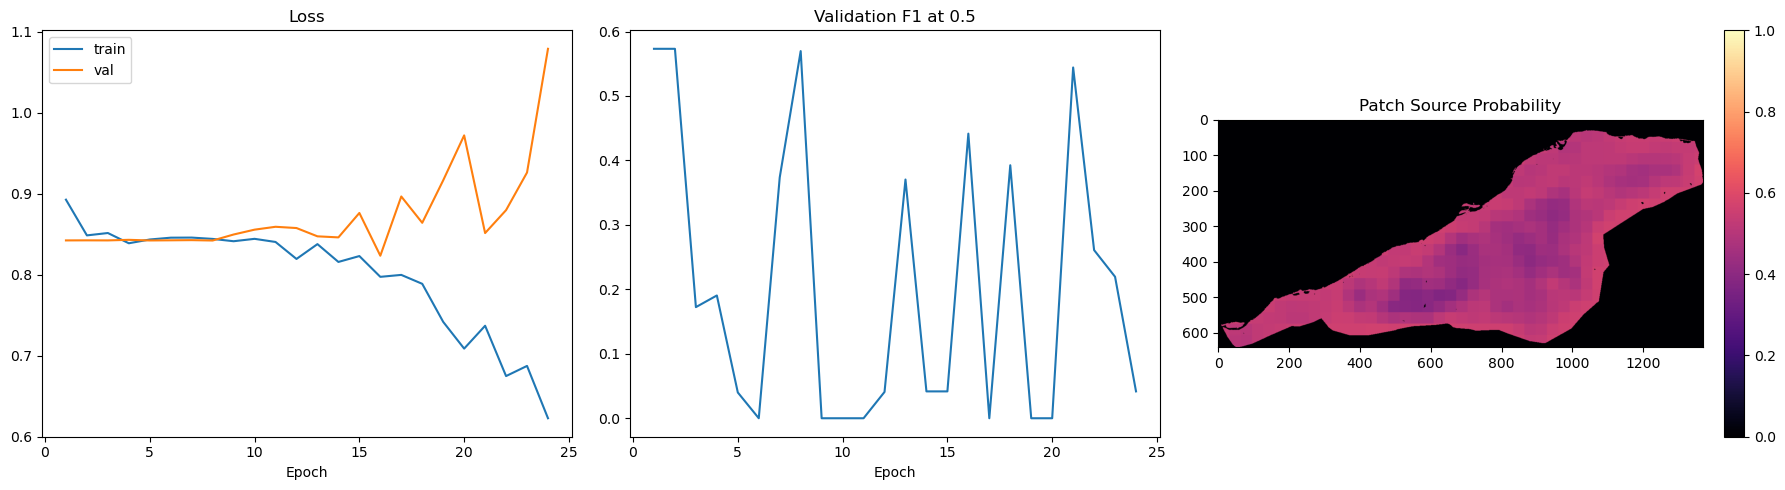

In [13]:
fig, axes = plt.subplots(1, 3, figsize=(18, 5))

axes[0].plot(history_df["epoch"], history_df["train_loss"], label="train")
axes[0].plot(history_df["epoch"], history_df["val_loss"], label="val")
axes[0].set_title("Loss")
axes[0].set_xlabel("Epoch")
axes[0].legend()

axes[1].plot(history_df["epoch"], history_df["val_f1_05"])
axes[1].set_title("Validation F1 at 0.5")
axes[1].set_xlabel("Epoch")

im = axes[2].imshow(prob_map, cmap="magma", vmin=0, vmax=1)
axes[2].set_title("Patch Source Probability")
plt.colorbar(im, ax=axes[2], fraction=0.046, pad=0.04)

plt.tight_layout()
plt.show()


In [58]:
from pathlib import Path
import sys
import json

import numpy as np
import pandas as pd
import geopandas as gpd
import rasterio
from rasterio.features import rasterize
import matplotlib.pyplot as plt

repo_root = Path("/home/abdullah/fire-debrisflow-ml")
src_dir = repo_root / "src"
if str(src_dir) not in sys.path:
    sys.path.insert(0, str(src_dir))

from deep.data import load_feature_target_stack, build_block_windows, split_block_windows

from sklearn.ensemble import RandomForestClassifier


In [60]:
aoi_path = Path("/mnt/c/Users/amehedi/Downloads/eaglecreek/eaglecreek.shp")
label_poly_path = Path("/mnt/c/Users/amehedi/Downloads/eaglecreek/eaglecreek_landslide_inventory_2009_2018.geojson")
features_dir = Path("/mnt/c/Users/amehedi/Downloads/eaglecreek/output/30m")

run_name = "ls_source_rf_pixel_30m"
run_dir = features_dir / run_name
run_dir.mkdir(parents=True, exist_ok=True)

feature_names = [
    "topographic__elevation",
    "topographic__slope",
    # "topographic__curvature",
    # "topographic__specific_contributing_area",
    # "burn__severity",
    "soil__thickness",
    # "soil__internal_friction_angle",
    "soil__mode_total_cohesion",
]

feature_paths = [features_dir / f"{name}.tif" for name in feature_names]
missing = [str(p) for p in feature_paths if not p.exists()]
if missing:
    raise FileNotFoundError("Missing features:\n" + "\n".join(missing))

ref_path = features_dir / "topographic__elevation.tif"
label_raster_path = run_dir / "landslide_label.tif"
prob_out_path = run_dir / "landslide_prob_rf.tif"
mask_out_path = run_dir / "landslide_pred_rf.tif"
threshold_path = run_dir / "threshold_sweep.csv"

block_size = 512
train_frac = 0.60
val_frac = 0.20
test_frac = 0.20
random_state = 42
max_split_retries = 100

label_buffer_pixels = 0
all_touched = True

train_neg_to_pos_ratio = 5.0
n_estimators = 500
min_samples_leaf = 2
max_depth = None

thresholds = [round(t, 2) for t in np.arange(0.05, 0.96, 0.05)]


In [61]:
def dilate_binary_mask(mask: np.ndarray, iterations: int = 1) -> np.ndarray:
    out = mask.astype(bool)
    for _ in range(iterations):
        padded = np.pad(out, 1, mode="constant", constant_values=False)
        neighbors = []
        for dr in (-1, 0, 1):
            for dc in (-1, 0, 1):
                neighbors.append(
                    padded[1 + dr : 1 + dr + out.shape[0], 1 + dc : 1 + dc + out.shape[1]]
                )
        out = np.logical_or.reduce(neighbors)
    return out.astype("uint8")


def binary_scores(y_true, y_prob, threshold=0.5):
    y_true = np.asarray(y_true).astype(np.uint8)
    y_pred = (np.asarray(y_prob) >= threshold).astype(np.uint8)

    tp = int(((y_pred == 1) & (y_true == 1)).sum())
    tn = int(((y_pred == 0) & (y_true == 0)).sum())
    fp = int(((y_pred == 1) & (y_true == 0)).sum())
    fn = int(((y_pred == 0) & (y_true == 1)).sum())

    precision = tp / max(tp + fp, 1)
    recall = tp / max(tp + fn, 1)
    f1 = 2 * precision * recall / max(precision + recall, 1e-8)
    iou = tp / max(tp + fp + fn, 1)
    acc = (tp + tn) / max(tp + tn + fp + fn, 1)

    return {
        "precision": precision,
        "recall": recall,
        "f1": f1,
        "iou": iou,
        "accuracy": acc,
        "tp": tp,
        "fp": fp,
        "fn": fn,
        "tn": tn,
    }


def save_float_tif(array, profile, out_path, nodata_value=-9999.0):
    out_profile = profile.copy()
    out_profile.update(driver="GTiff", dtype="float32", count=1, nodata=nodata_value, compress="lzw")
    with rasterio.open(out_path, "w", **out_profile) as dst:
        dst.write(array.astype("float32"), 1)


def save_uint8_tif(array, profile, out_path, nodata_value=255):
    out_profile = profile.copy()
    out_profile.update(driver="GTiff", dtype="uint8", count=1, nodata=nodata_value, compress="lzw")
    with rasterio.open(out_path, "w", **out_profile) as dst:
        dst.write(array.astype("uint8"), 1)


def build_spatial_split_masks(valid_mask, y, block_size=512, train_frac=0.6, val_frac=0.2, test_frac=0.2,
                              random_state=42, max_retries=100, min_pos=None):
    if min_pos is None:
        min_pos = {"train": 50, "val": 20, "test": 20}

    windows = build_block_windows(y.shape[0], y.shape[1], block_size=block_size)

    for attempt in range(max_retries):
        split_windows = split_block_windows(
            windows,
            train_frac=train_frac,
            val_frac=val_frac,
            test_frac=test_frac,
            random_state=random_state + attempt,
        )

        masks = {}
        ok = True
        for split_name in ("train", "val", "test"):
            m = np.zeros_like(valid_mask, dtype=bool)
            for w in split_windows[split_name]:
                m[w.row0:w.row1, w.col0:w.col1] = True
            m &= valid_mask
            masks[split_name] = m

            if int(y[m].sum()) < min_pos[split_name]:
                ok = False
                break

        if ok:
            return split_windows, masks, random_state + attempt

    raise ValueError("Could not find a spatial split with enough positive pixels.")


def sample_balanced_train_pixels(split_mask, y, neg_to_pos_ratio=5.0, random_state=42):
    rows, cols = np.where(split_mask)
    labels = y[rows, cols].astype(np.uint8)

    pos_idx = np.flatnonzero(labels == 1)
    neg_idx = np.flatnonzero(labels == 0)

    if len(pos_idx) == 0:
        raise ValueError("No positive training pixels in the split.")

    rng = np.random.default_rng(random_state)
    n_neg_keep = min(len(neg_idx), int(np.ceil(len(pos_idx) * neg_to_pos_ratio)))
    neg_keep = rng.choice(neg_idx, size=n_neg_keep, replace=False) if n_neg_keep > 0 else np.array([], dtype=int)

    keep = np.concatenate([pos_idx, neg_keep])
    rng.shuffle(keep)

    return rows[keep], cols[keep], labels[keep]


def matrix_from_coords(X, rows, cols):
    return X[:, rows, cols].T.astype("float32")


In [62]:
with rasterio.open(ref_path) as src:
    ref_profile = src.profile.copy()
    ref_crs = src.crs
    ref_transform = src.transform
    ref_arr = src.read(1)
    ref_nodata = src.nodata if src.nodata is not None else -9999.0

valid_ref = np.isfinite(ref_arr) & (~np.isclose(ref_arr, ref_nodata))

aoi = gpd.read_file(aoi_path).to_crs(ref_crs)
labels = gpd.read_file(label_poly_path).to_crs(ref_crs)
labels = gpd.overlay(labels, aoi[["geometry"]], how="intersection")
labels = labels[~labels.geometry.is_empty].copy()

label_arr = rasterize(
    ((geom, 1) for geom in labels.geometry),
    out_shape=ref_arr.shape,
    transform=ref_transform,
    fill=0,
    all_touched=all_touched,
    dtype="uint8",
)

if label_buffer_pixels > 0:
    label_arr = dilate_binary_mask(label_arr, iterations=label_buffer_pixels)

label_arr[~valid_ref] = 255

label_profile = ref_profile.copy()
label_profile.update(driver="GTiff", dtype="uint8", count=1, nodata=255, compress="lzw")
with rasterio.open(label_raster_path, "w", **label_profile) as dst:
    dst.write(label_arr, 1)

print("Saved:", label_raster_path)
print("Positive pixels:", int((label_arr == 1).sum()))
print("Valid pixels:", int((label_arr != 255).sum()))


Saved: /mnt/c/Users/amehedi/Downloads/eaglecreek/output/30m/ls_source_rf_pixel_30m/landslide_label.tif
Positive pixels: 990
Valid pixels: 375359


In [63]:
stack = load_feature_target_stack(feature_paths, label_raster_path)

X = stack["X"].astype("float32")
y = (stack["y"] > 0).astype("uint8")
valid_mask = stack["valid_mask"]
profile = stack["profile"]

print("X shape:", X.shape)
print("Positive fraction:", float(y[valid_mask].mean()))


X shape: (4, 642, 1368)
Positive fraction: 0.0028596600181978364


In [64]:
split_windows, split_masks, split_seed = build_spatial_split_masks(
    valid_mask=valid_mask,
    y=y,
    block_size=block_size,
    train_frac=train_frac,
    val_frac=val_frac,
    test_frac=test_frac,
    random_state=random_state,
    max_retries=max_split_retries,
    min_pos={"train": 50, "val": 20, "test": 20},
)

train_rows, train_cols, y_train = sample_balanced_train_pixels(
    split_masks["train"],
    y,
    neg_to_pos_ratio=train_neg_to_pos_ratio,
    random_state=split_seed,
)

val_rows, val_cols = np.where(split_masks["val"])
y_val = y[val_rows, val_cols].astype(np.uint8)

test_rows, test_cols = np.where(split_masks["test"])
y_test = y[test_rows, test_cols].astype(np.uint8)

X_train = matrix_from_coords(X, train_rows, train_cols)
X_val = matrix_from_coords(X, val_rows, val_cols)
X_test = matrix_from_coords(X, test_rows, test_cols)

pd.DataFrame(
    [
        {"split": "train_balanced", "pixels": len(y_train), "positives": int(y_train.sum()), "negatives": int((y_train == 0).sum())},
        {"split": "val_natural", "pixels": len(y_val), "positives": int(y_val.sum()), "negatives": int((y_val == 0).sum())},
        {"split": "test_natural", "pixels": len(y_test), "positives": int(y_test.sum()), "negatives": int((y_test == 0).sum())},
    ]
)


,split,pixels,positives,negatives
0,train_balanced,1698,283,1415
1,val_natural,156026,423,155603
2,test_natural,23808,284,23524


In [ ]:
rf = RandomForestClassifier(
    n_estimators=n_estimators,
    max_depth=max_depth,
    min_samples_leaf=min_samples_leaf,
    class_weight="balanced_subsample",
    random_state=split_seed,
    n_jobs=-1,
    verbose=0,
)

rf.fit(X_train, y_train)

val_prob = rf.predict_proba(X_val)[:, 1]
test_prob = rf.predict_proba(X_test)[:, 1]

threshold_rows = []
for threshold in thresholds:
    val_scores = binary_scores(y_val, val_prob, threshold=threshold)
    test_scores = binary_scores(y_test, test_prob, threshold=threshold)

    threshold_rows.append(
        {
            "threshold": threshold,
            "val_precision": val_scores["precision"],
            "val_recall": val_scores["recall"],
            "val_f1": val_scores["f1"],
            "val_iou": val_scores["iou"],
            "test_precision": test_scores["precision"],
            "test_recall": test_scores["recall"],
            "test_f1": test_scores["f1"],
            "test_iou": test_scores["iou"],
        }
    )

threshold_df = pd.DataFrame(threshold_rows)
threshold_df.to_csv(threshold_path, index=False)

best_idx = threshold_df["val_f1"].idxmax()
best_threshold = float(threshold_df.loc[best_idx, "threshold"])

print("Best threshold:", best_threshold)
threshold_df.sort_values("val_f1", ascending=False).head(10)

Best threshold: 0.35


,threshold,val_precision,val_recall,val_f1,val_iou,test_precision,test_recall,test_f1,test_iou
6,0.35,0.009343,0.524823,0.018359,0.009265,0.022321,0.496479,0.042721,0.021827
7,0.40,0.009043,0.442080,0.017723,0.008941,0.021468,0.429577,0.040892,0.020873
5,0.30,0.008685,0.553191,0.017101,0.008624,0.022943,0.552817,0.044058,0.022525
4,0.25,0.008468,0.609929,0.016704,0.008423,0.022787,0.605634,0.043922,0.022454
3,0.20,0.007989,0.654846,0.015786,0.007956,0.023821,0.693662,0.046060,0.023573
8,0.45,0.008062,0.340426,0.015751,0.007938,0.021036,0.380282,0.039867,0.020339
9,0.50,0.007649,0.276596,0.014886,0.007499,0.021949,0.352113,0.041322,0.021097
2,0.15,0.007496,0.706856,0.014835,0.007473,0.024650,0.781690,0.047793,0.024482
10,0.55,0.007091,0.208038,0.013715,0.006905,0.022831,0.316901,0.042593,0.021760
17,0.90,0.009989,0.021277,0.013595,0.006844,0.012635,0.024648,0.016706,0.008424


In [ ]:
rows_all, cols_all = np.where(valid_mask)
X_all = matrix_from_coords(X, rows_all, cols_all)
prob_all = rf.predict_proba(X_all)[:, 1].astype("float32")

prob_full = np.full(y.shape, -9999.0, dtype="float32")
prob_full[rows_all, cols_all] = prob_all

pred_full = np.full(y.shape, 255, dtype="uint8")
pred_full[rows_all, cols_all] = (prob_all >= best_threshold).astype("uint8")

save_float_tif(prob_full, profile, prob_out_path, nodata_value=-9999.0)
save_uint8_tif(pred_full, profile, mask_out_path, nodata_value=255)

print("Saved:", prob_out_path)
print("Saved:", mask_out_path)

Saved: /mnt/c/Users/amehedi/Downloads/eaglecreek/output/30m/ls_source_rf_pixel_30m/landslide_prob_rf.tif
Saved: /mnt/c/Users/amehedi/Downloads/eaglecreek/output/30m/ls_source_rf_pixel_30m/landslide_pred_rf.tif


In [67]:
importance = pd.Series(rf.feature_importances_, index=feature_names).sort_values(ascending=False)
importance

topographic__elevation       0.399605
soil__thickness              0.260393
soil__mode_total_cohesion    0.193715
topographic__slope           0.146287
dtype: float64

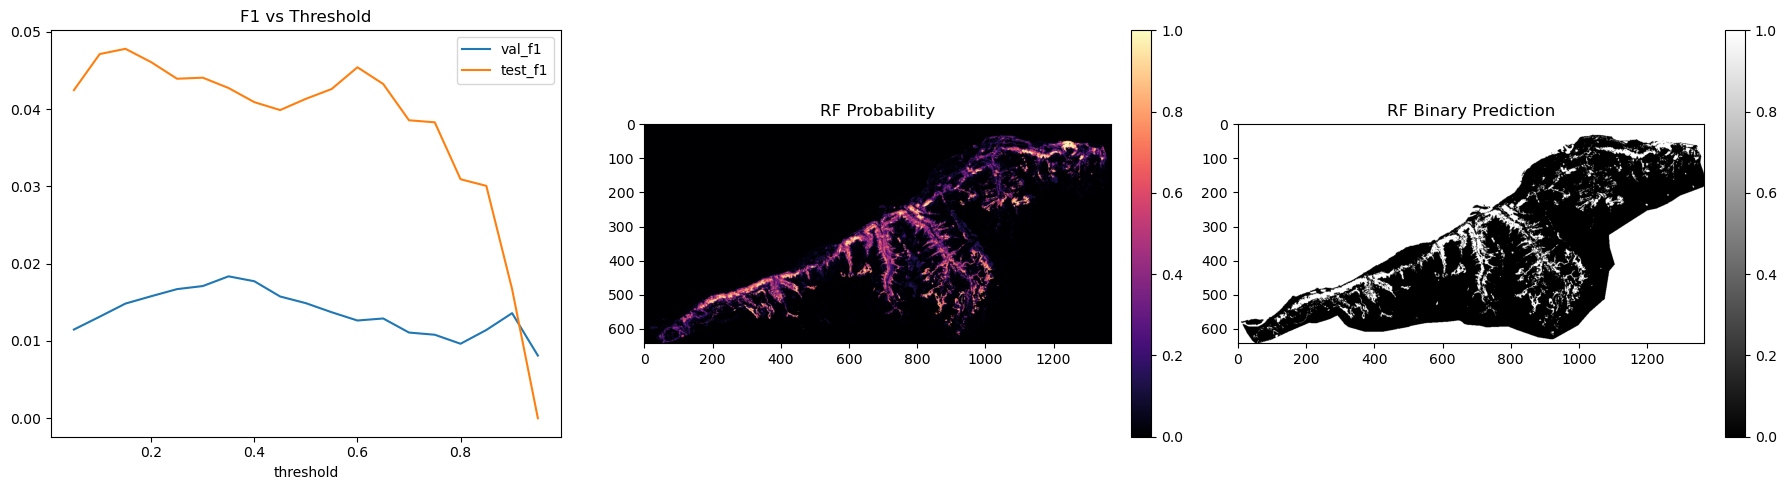

In [68]:
fig, axes = plt.subplots(1, 3, figsize=(18, 5))

threshold_df.plot(x="threshold", y=["val_f1", "test_f1"], ax=axes[0])
axes[0].set_title("F1 vs Threshold")

im1 = axes[1].imshow(prob_full, cmap="magma", vmin=0, vmax=1)
axes[1].set_title("RF Probability")
plt.colorbar(im1, ax=axes[1], fraction=0.046, pad=0.04)

im2 = axes[2].imshow(pred_full, cmap="gray", vmin=0, vmax=1)
axes[2].set_title("RF Binary Prediction")
plt.colorbar(im2, ax=axes[2], fraction=0.046, pad=0.04)

plt.tight_layout()
plt.show()
